# Multi-sample cell typing

# Dependencies and preparation


In [ ]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [ ]:
import anndata as ad
import scripts
from scripts.celltype_rules_IHOPE import assign_cell_types_bool_IHOPE
from scripts.spatial_plot import spatial_celltype_plot
from scripts.summary_celltypes_IHOPE import summarize_celltypes_IHOPE
from scripts.anndata_helpers import load_and_build_anndata, save_h5ad

In [ ]:
import scripts
import scripts.spatial_plot
import importlib

importlib.reload(scripts.spatial_plot)

Define sample base names:

In [ ]:
samples = [
"IHOPE14_MedLN_BottomLeft",
"IHOPE14_MedLN_BottomRight",
"IHOPE14_MedLN_TopRight",
"IHOPE14_mesLN", #this one may also have _RAW_RESULTS in name
"IHOPE20_LN",
"IHOPE20_Spleen",
"IHOPE26_LN",
"IHOPE26_Spleen",
"IHOPE27_LN",
"IHOPE27_Spleen",
"IHOPE39_LN",
"IHOPE39_MesLN_1",
]

In [ ]:
from scripts.spatial_plot import spatial_celltype_plot

for basename in samples:

    try:
        print(f"Processing {basename}")

        input_path = (
            f"../data/processed/anndata/"
            f"{basename}_filtered_arcsinh_cf5_GMM_IHOPE_celltypes_banksy.h5ad"
        )

        output_path = (
            f"../data/processed/anndata/"
            f"{basename}_filtered_arcsinh_cf5_GMM_IHOPE_celltypes_updated_banksy.h5ad"
        )

        # Load data
        adata = ad.read_h5ad(input_path)
        print(f"Loaded {adata.n_obs} cells")

        # Run cell typing
        adata = assign_cell_types_bool_IHOPE(adata)

        # Type plots
        celltype_cols = [
            c for c in adata.obs.columns
            if c.startswith("type_")
            and not c.endswith("unclassified")
            and not c.endswith("Endothelial")
        ]

        spatial_celltype_plot(
            adata,
            celltype_cols,
            min_cells=50,
            title = f"{basename}"
        )

        # T subtype plots
        t_subtypes = [
            c for c in adata.obs.columns
            if c.startswith("subtype_T")
        ]

        spatial_celltype_plot(
            adata,
            celltype_cols=t_subtypes,
            min_cells=15,
            size=10,
            alpha=0.7,
            title = f"{basename}"
        )

        # B subtype plots
        b_subtypes = [
            c for c in adata.obs.columns
            if c.startswith("subtype_B_")
        ]

        spatial_celltype_plot(
            adata,
            celltype_cols=b_subtypes,
            min_cells=15,
            size=10,
            alpha=0.7,
            title = f"{basename}"
        )

        # Summary table
        df_summary = summarize_celltypes_IHOPE(
            adata,
            filename=f"{basename}_filtered_arcsinh_cf5.0_IHOPE_summary.csv"
        )

        # Save anndata
        save_h5ad(adata, output_path)

        print(f"Saved: {output_path}")

    except Exception as e:
        print(f"Error in {basename}: {e}")


# Update below

Imports and preparation

In [21]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad

# Cell typing & spatial plotting scripts
from scripts.celltype_rules_IHOPE import assign_cell_types_bool_IHOPE
from scripts.summary_celltypes_IHOPE import summarize_celltypes_IHOPE
from scripts.spatial_plot import spatial_celltype_plot

# B-cell domain analysis
from scripts.banksy_domains import (
    compute_domain_bcell_stats,
    plot_domains_by_bcell_fraction,
    assign_bcell_follicles,
    plot_bcell_follicles
)

Sample names and paths

In [22]:
samples = [
    "IHOPE14_MedLN_BottomLeft",
    "IHOPE14_Spleen",
    "IHOPE20_LN",
    "IHOPE26_LN",
    "IHOPE26_Spleen_2",
    "IHOPE26_Spleen",
    "IHOPE27_LN",
    "IHOPE27_Spleen",
    "IHOPE39_LN",
    "IHOPE39_MesLN_1",
    "IHOPE39_MesLN",
    "IHOPE39_Spleen"
]

input_dir = "../data/processed/anndata"
output_dir = "../data/processed/anndata"
os.makedirs(output_dir, exist_ok=True)


Loop over samples to apply cell typing

In [23]:
adatas = {}  # keep for plotting grids

for basename in samples:
    try:
        print(f"Processing {basename}")


        # Try cf5 first
        input_path = os.path.join(
        input_dir,
        f"{basename}_filtered_arcsinh_cf5_GMM_IHOPE_celltypes_banksy.h5ad"
)

        # If not found, try cf5.0
        if not os.path.exists(input_path):
            input_path = os.path.join(
                input_dir,
                f"{basename}_filtered_arcsinh_cf5.0_GMM_IHOPE_celltypes_banksy.h5ad"
            )

        if not os.path.exists(input_path):
            raise FileNotFoundError(f"No cf5 or cf5.0 file found for {basename}")

        # Load AnnData
        adata = ad.read_h5ad(input_path)
        print(f"Loaded {adata.n_obs} cells")

        # Assign / update cell types
        adata = assign_cell_types_bool_IHOPE(adata)

        # Store for later grid plotting
        adatas[basename] = adata

        # Save updated AnnData
        adata.write_h5ad(output_path)
        print(f"Saved: {output_path}")

    except Exception as e:
        print(f"Error in {basename}: {e}")


Processing IHOPE14_MedLN_BottomLeft
Loaded 112174 cells
Total cells: 112174

Level — type:
  type_B: 2747 (2.4% of total)
  type_T: 22530 (20.1% of total)
  type_unclassified: 47971 (42.8% of total)
  type_CD4_T: 32388 (28.9% of total)
  type_CD8_T: 7210 (6.4% of total)
  type_NK: 152 (0.1% of total)
  type_Myeloid: 7436 (6.6% of total)
  type_Stromal: 17271 (15.4% of total)
  type_Endothelial: 18341 (16.4% of total)

Level — intermediate:
  intermediate_CD4_T: 11953 (10.7% of total)
  intermediate_CD8_T: 3865 (3.4% of total)
  intermediate_T_naive: 669 (0.6% of total)
  intermediate_T_memory: 10498 (9.4% of total)
  intermediate_B_naive: 113 (0.1% of total)
  intermediate_B_memory: 1081 (1.0% of total)

Level — subtype:
  subtype_B_naive_like: 5 (0.0% of total)
  subtype_B_memory_like: 23 (0.0% of total)
  subtype_B_GC_like: 18 (0.0% of total)
  subtype_B_plasmablast: 579 (0.5% of total)
  subtype_TN_CD4: 507 (0.5% of total)
  subtype_TN_CD8: 41 (0.0% of total)
  subtype_TCM_CD4: 7338

Visualize cell types (type)

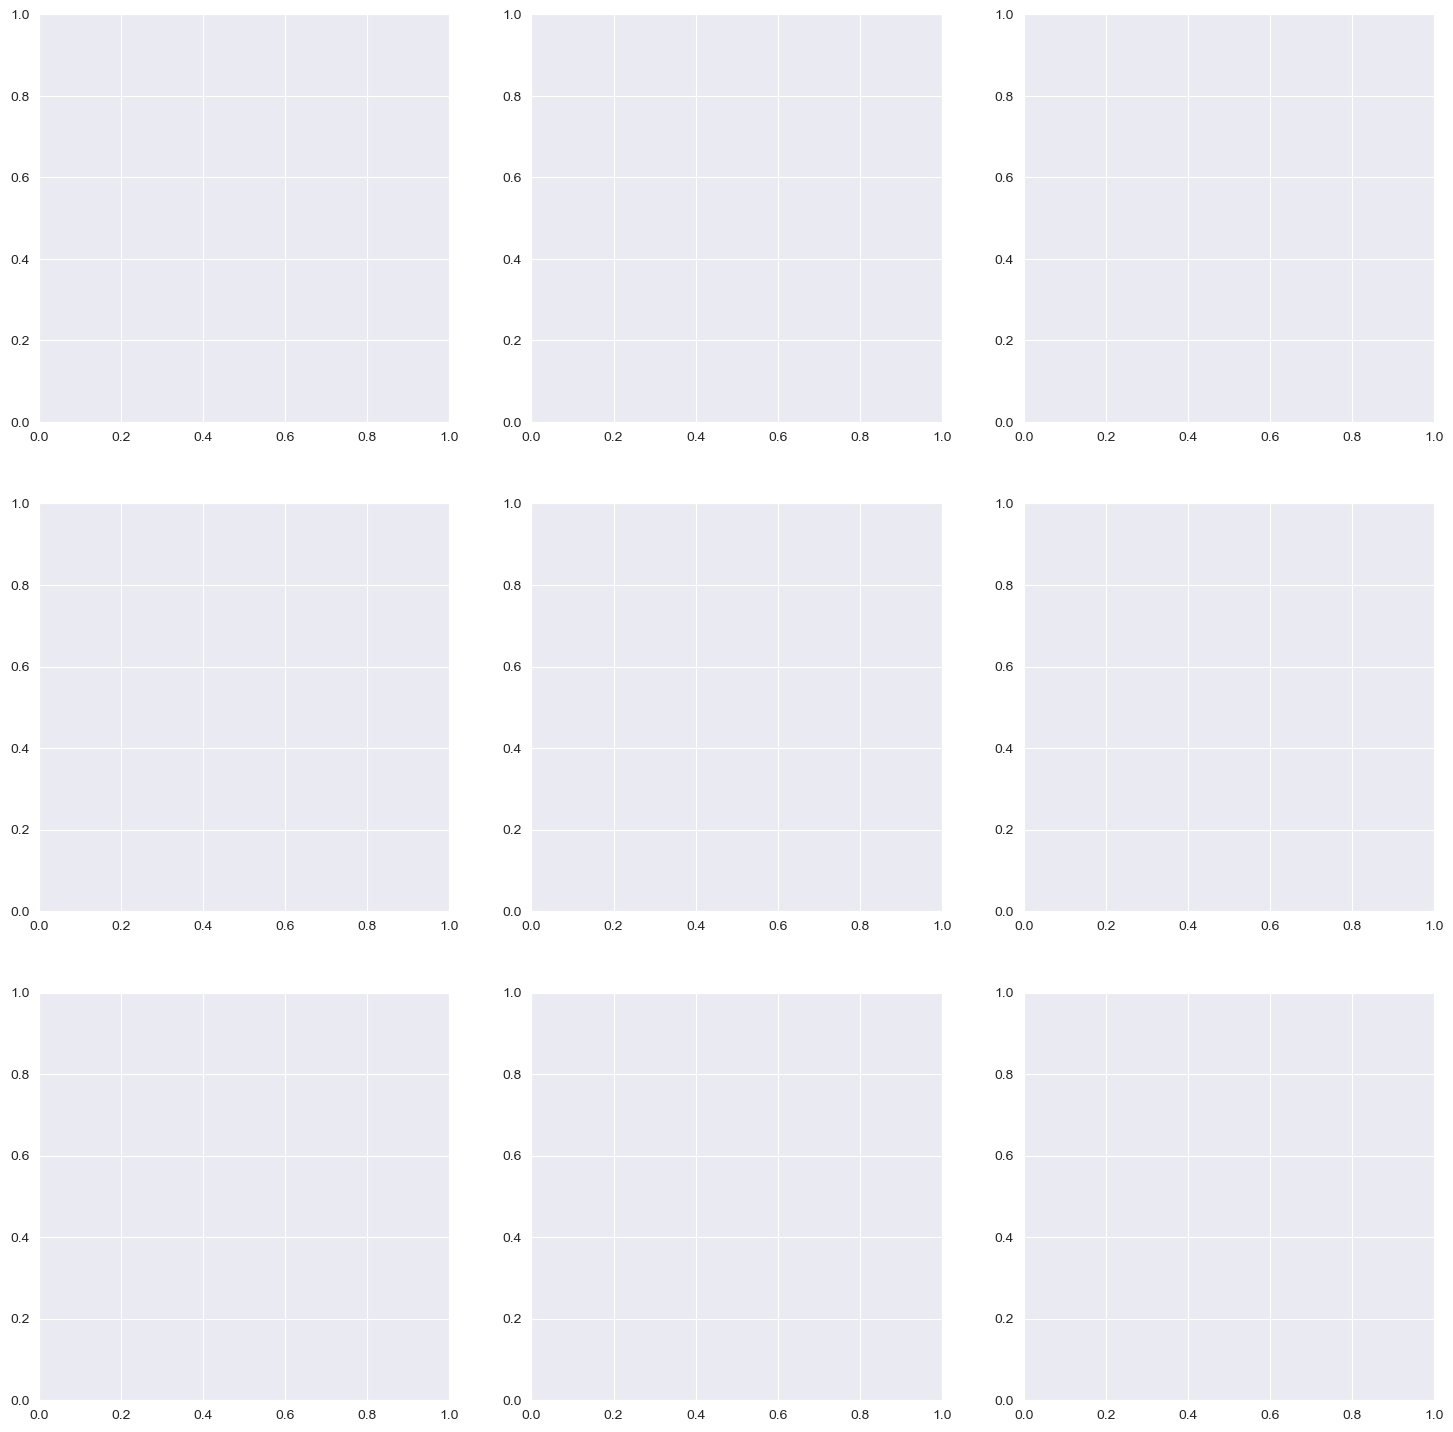

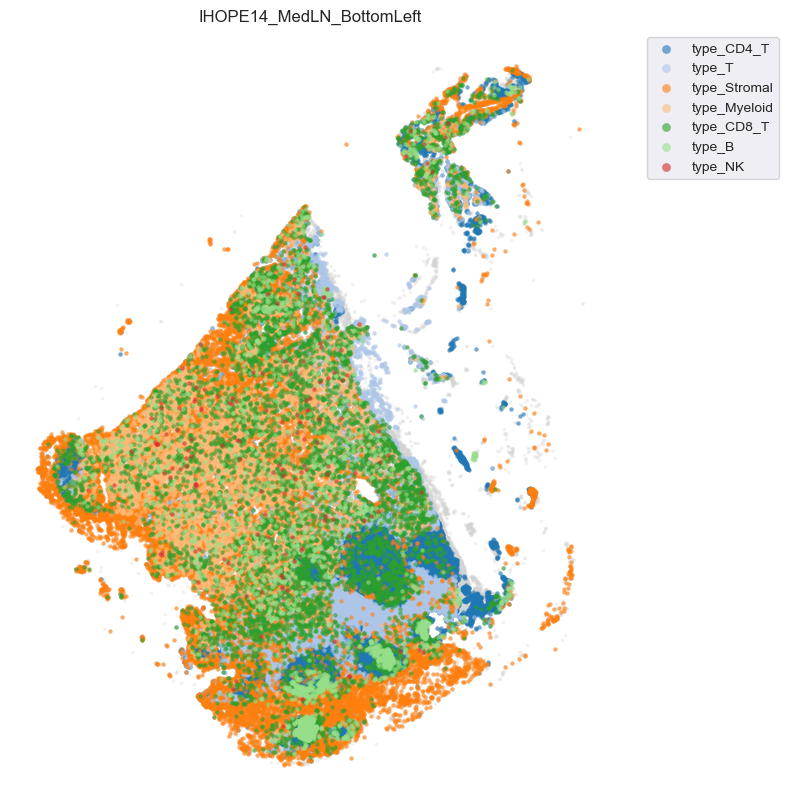

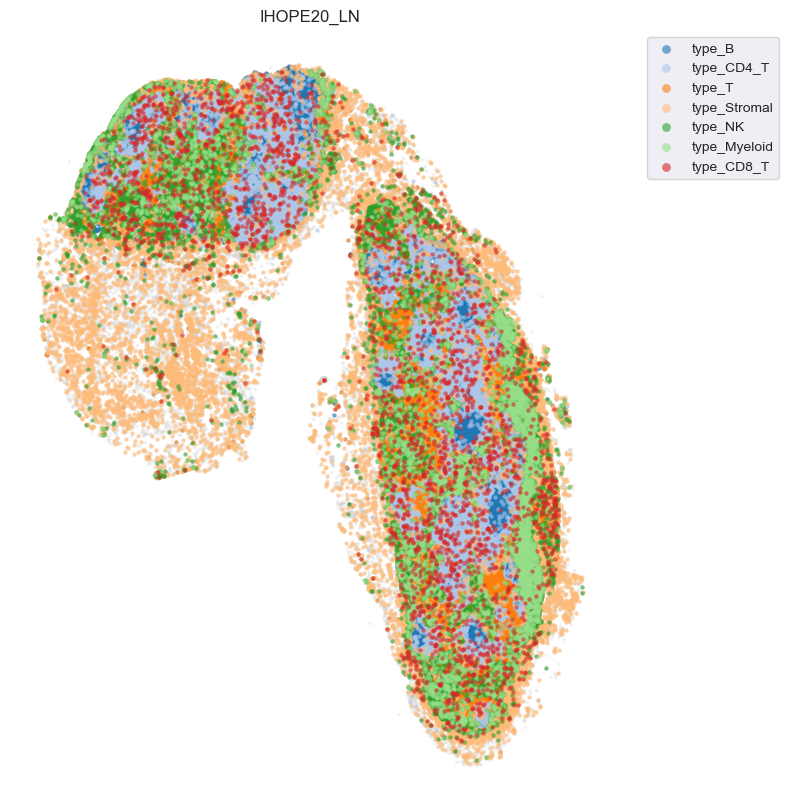

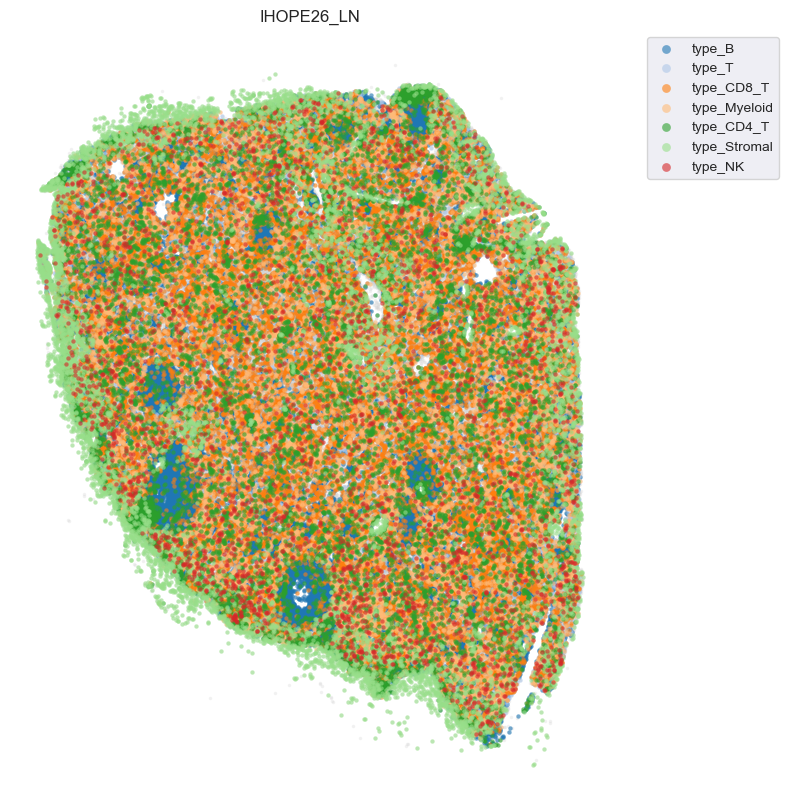

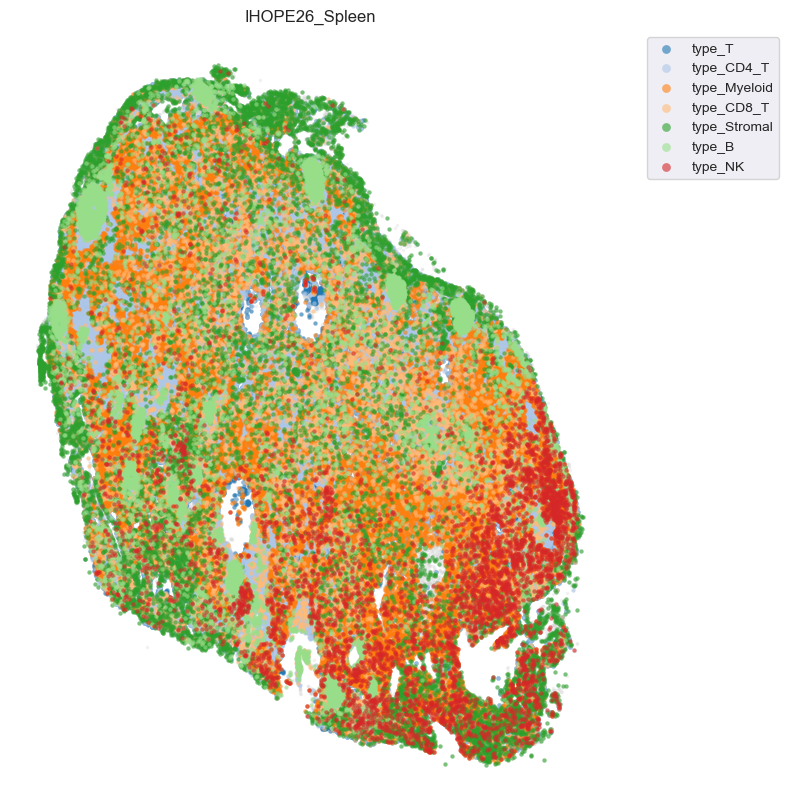

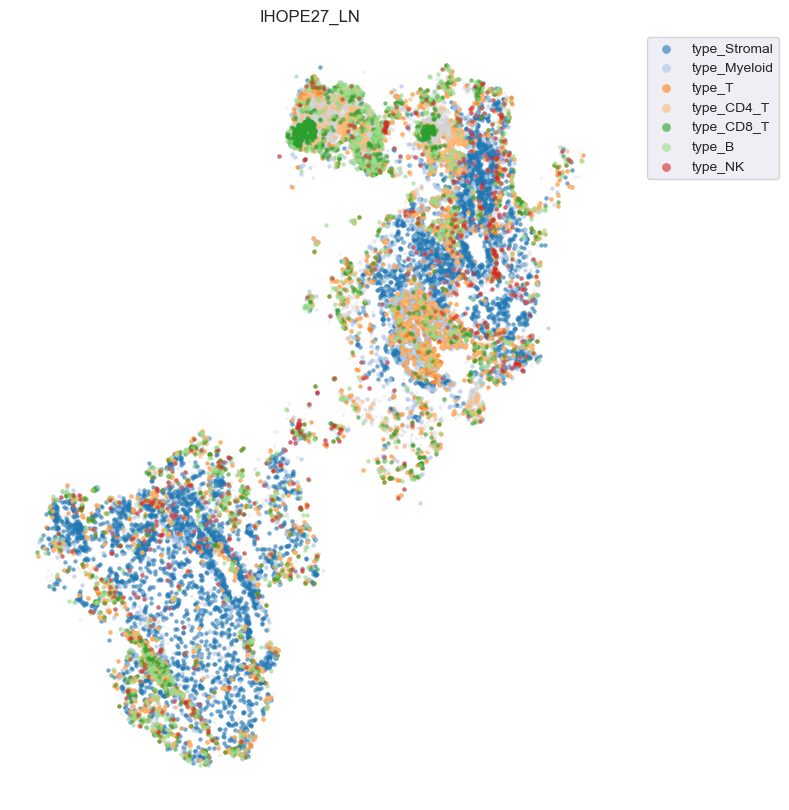

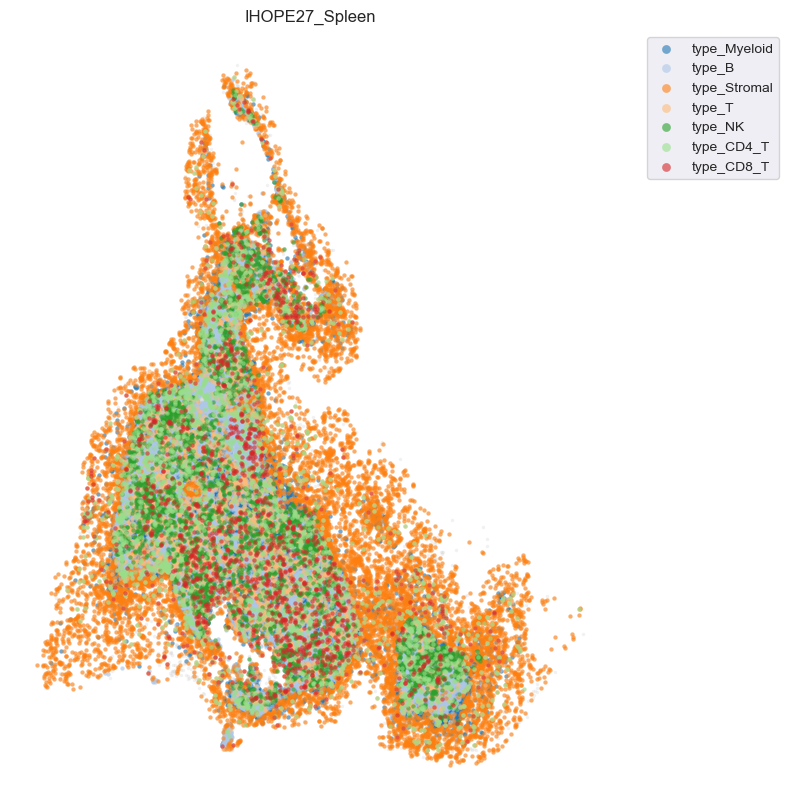

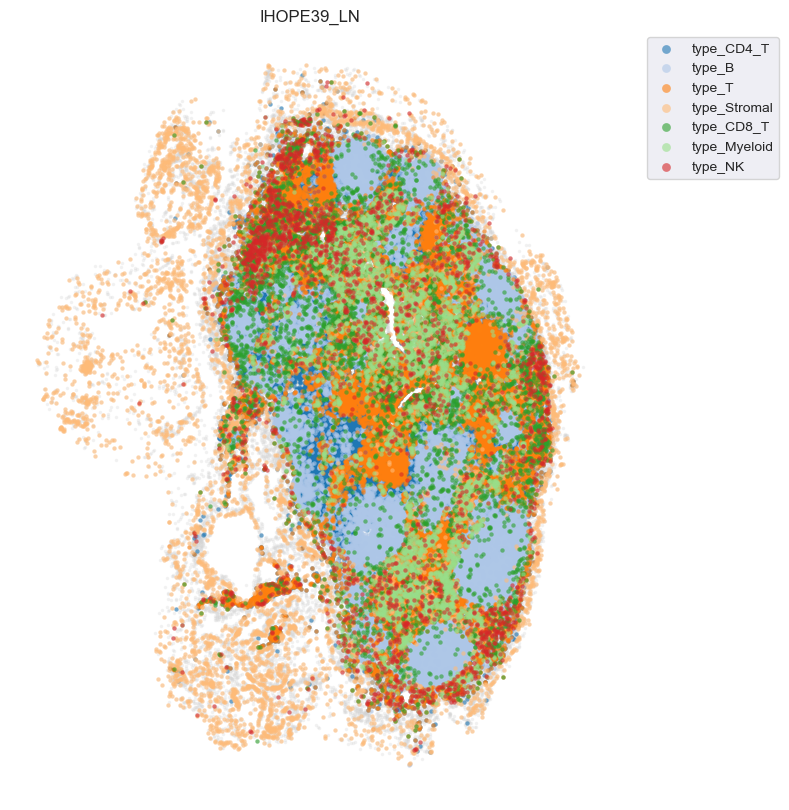

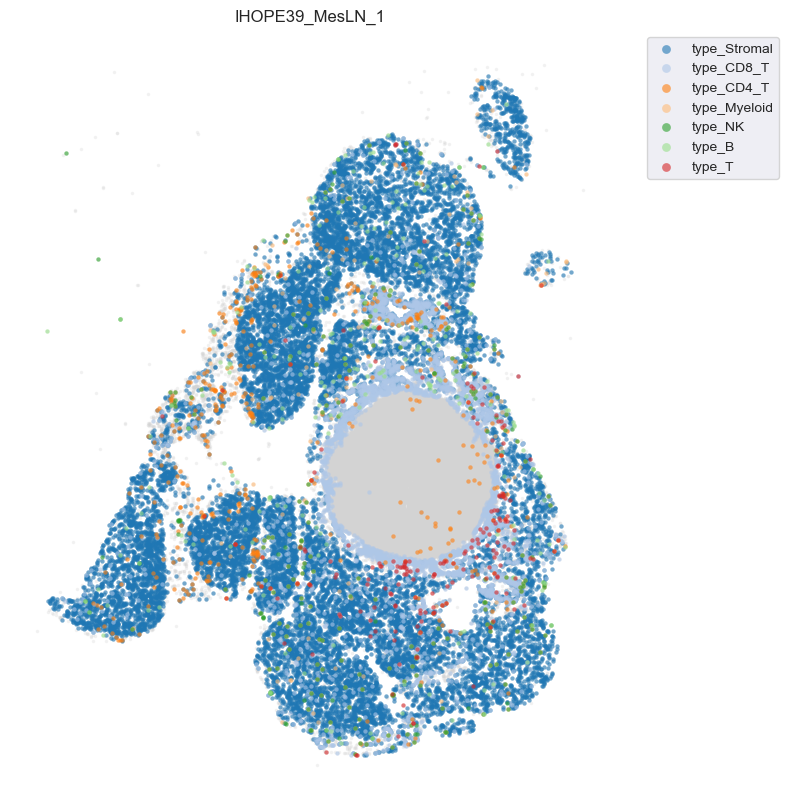

<Figure size 640x480 with 0 Axes>

In [24]:
fig, axes = plt.subplots(
    nrows=len(adatas)//3 + 1, ncols=3, figsize=(18, 6 * ((len(adatas)//3)+1))
)
axes = axes.flatten()

for ax, (basename, adata) in zip(axes, adatas.items()):
    celltype_cols = [
        c for c in adata.obs.columns
        if c.startswith("type_") and not c.endswith(("unclassified", "Endothelial"))
    ]

    # Use the plotting function but direct to ax
    spatial_celltype_plot(
        adata,
        celltype_cols,
        min_cells=50,
        title=basename
    )

plt.tight_layout()
plt.show()

#TODO repeat for intermediate (intermediate_*) or subtype (subtype_*) levels
#TODO fix the grid

Compute & plot B cell domains

/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/scripts/banksy_domains.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for domain, idx in adata.obs.groupby(banksy_domain_key).groups.items():


BANKSY domains ranked by B-cell fraction:
domain  n_cells   frac_B   frac_T  B_T_ratio
     8     6202 0.171880 0.000484 355.333333
     2    15145 0.032156 0.215054   0.149524
     7     7215 0.026057 0.172834   0.150762
     6     7726 0.020450 0.330313   0.061912
     0    17827 0.019409 0.162955   0.119105
     5     9310 0.017615 0.496778   0.035459
     3    11797 0.015258 0.040688   0.375000
    10     2541 0.012593 0.377017   0.033403
    11     2374 0.006740 0.000842   8.000000
     4    11400 0.005263 0.001930   2.727273
     1    15818 0.003161 0.254583   0.012416
     9     4743 0.000000 0.516972   0.000000
    12       76 0.000000 0.000000        NaN


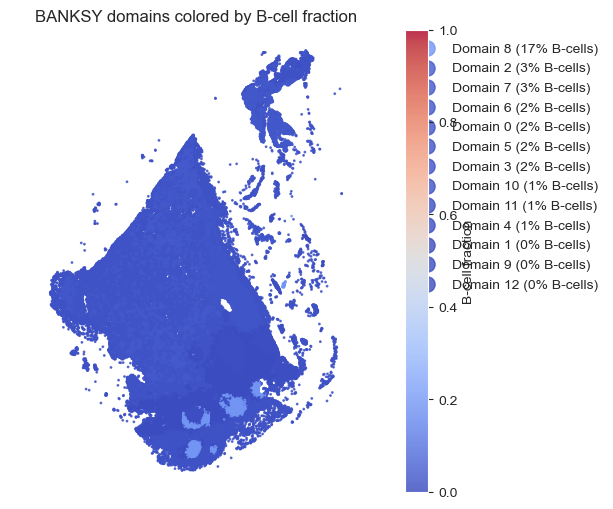

/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/scripts/banksy_domains.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for domain, idx in adata.obs.groupby(banksy_domain_key).groups.items():


BANKSY domains ranked by B-cell fraction:
domain  n_cells   frac_B   frac_T   B_T_ratio
     6    10615 0.878285 0.000754 1165.375000
     0    26838 0.574931 0.004136  139.009009
     3    18925 0.451096 0.008613   52.374233
     1    25107 0.286414 0.237543    1.205734
     5    12250 0.139347 0.267673    0.520586
     8     5406 0.094525 0.159083    0.594186
     9     4618 0.085751 0.267215    0.320908
     2    22852 0.083056 0.377647    0.219930
     7     9302 0.076220 0.069770    1.092450
    10     2714 0.033161 0.063007    0.526316
     4    17727 0.001974 0.040954    0.048209


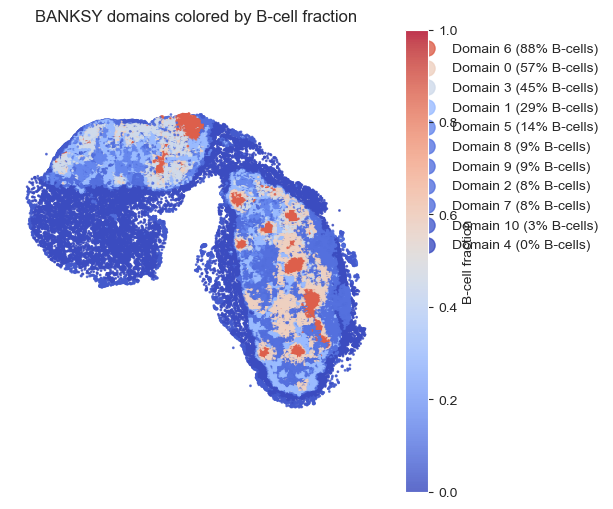

/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/scripts/banksy_domains.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for domain, idx in adata.obs.groupby(banksy_domain_key).groups.items():


BANKSY domains ranked by B-cell fraction:
domain  n_cells   frac_B   frac_T  B_T_ratio
     5    20714 0.714975 0.003090 231.406250
     1    39220 0.278149 0.139776   1.989967
     2    27983 0.197799 0.172712   1.145251
     4    21418 0.175553 0.178541   0.983264
     7    11722 0.104504 0.123187   0.848338
     3    24790 0.103066 0.446228   0.230971
     6    17723 0.099870 0.195960   0.509646
     0    43469 0.077504 0.080747   0.959829


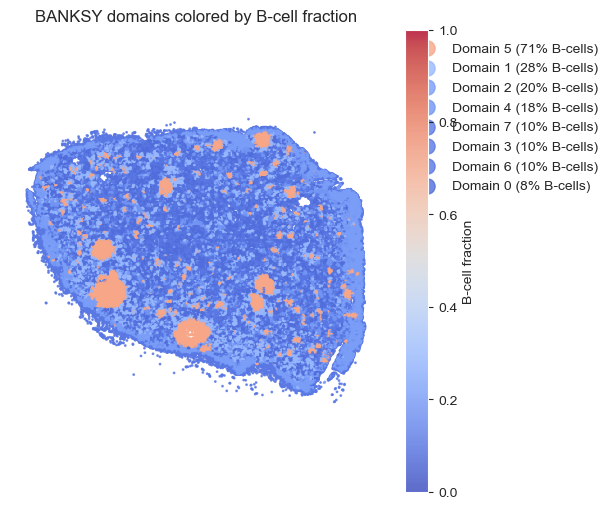

/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/scripts/banksy_domains.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for domain, idx in adata.obs.groupby(banksy_domain_key).groups.items():


BANKSY domains ranked by B-cell fraction:
domain  n_cells   frac_B   frac_T   B_T_ratio
     9     8066 0.350112 0.000124 2824.000000
    10     5126 0.296137 0.004682   63.250000
     6    15702 0.167049 0.010190   16.393750
     7    13681 0.047292 0.160807    0.294091
     5    16683 0.037343 0.322904    0.115649
     3    31242 0.033160 0.293611    0.112940
     2    36723 0.030825 0.478447    0.064428
     4    19020 0.019664 0.127708    0.153973
     1    40141 0.019207 0.372338    0.051586
     0    42346 0.009304 0.539838    0.017235
     8     9057 0.005521 0.432262    0.012771
    12      280 0.003571 0.175000    0.020408
    11      311 0.000000 0.000000         NaN


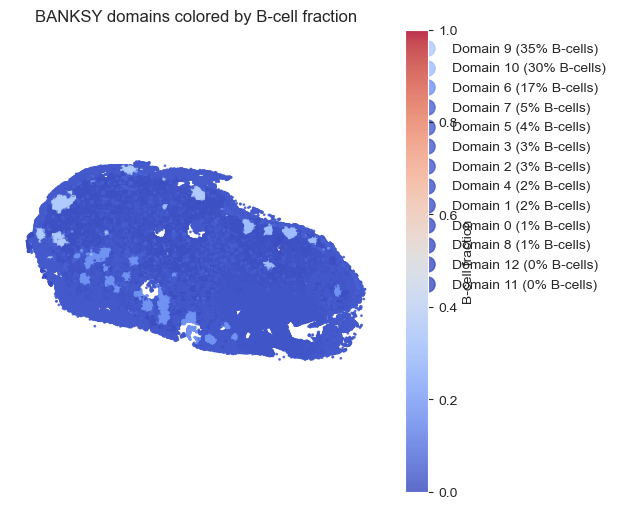

/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/scripts/banksy_domains.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for domain, idx in adata.obs.groupby(banksy_domain_key).groups.items():


BANKSY domains ranked by B-cell fraction:
domain  n_cells   frac_B   frac_T  B_T_ratio
     8       68 0.161765 0.029412   5.500000
     0     5557 0.119669 0.189311   0.632129
     3     2178 0.113866 0.304867   0.373494
     4     2171 0.085675 0.032243   2.657143
     1     3834 0.039645 0.103026   0.384810
     6     1358 0.016937 0.032401   0.522727
     5     1804 0.004435 0.014412   0.307692
     2     2674 0.002992 0.009349   0.320000
     7      935 0.000000 0.000000        NaN


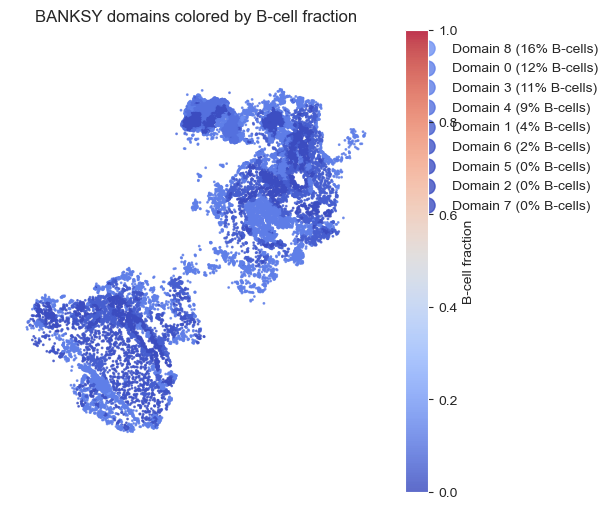

/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/scripts/banksy_domains.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for domain, idx in adata.obs.groupby(banksy_domain_key).groups.items():


BANKSY domains ranked by B-cell fraction:
domain  n_cells   frac_B   frac_T  B_T_ratio
     7      407 0.813268 0.000000        NaN
     0    15974 0.415675 0.095968   4.331376
     1    11651 0.267531 0.161274   1.658861
     3     9332 0.159666 0.136305   1.171384
     6     3390 0.152212 0.092625   1.643312
     5     3405 0.152129 0.083113   1.830389
     4     5842 0.123588 0.066587   1.856041
     2     9773 0.017293 0.045022   0.384091


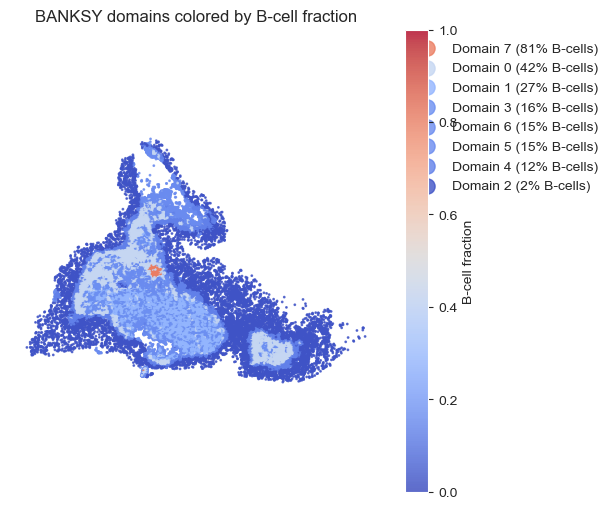

/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/scripts/banksy_domains.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for domain, idx in adata.obs.groupby(banksy_domain_key).groups.items():


BANKSY domains ranked by B-cell fraction:
domain  n_cells   frac_B   frac_T  B_T_ratio
    10     1464 0.932377 0.000000        NaN
     8     8029 0.890148 0.000000        NaN
     3    16026 0.505179 0.014976  33.733333
     5    12473 0.415938 0.003688 112.782609
     2    20658 0.191984 0.069852   2.748441
     6    11726 0.157087 0.145062   1.082892
     7    10133 0.153952 0.366032   0.420599
     1    21767 0.105113 0.421142   0.249591
     0    23453 0.088603 0.333518   0.265661
     9     3156 0.058935 0.607098   0.097077
    11     1100 0.036364 0.509091   0.071429
     4    14486 0.016154 0.039279   0.411248


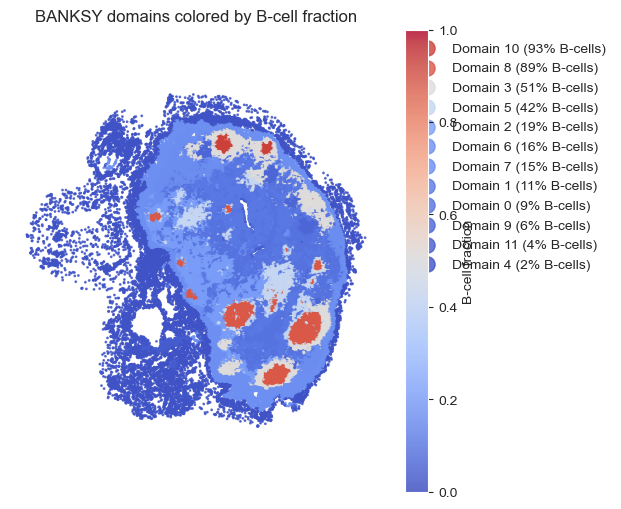

/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/scripts/banksy_domains.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for domain, idx in adata.obs.groupby(banksy_domain_key).groups.items():


BANKSY domains ranked by B-cell fraction:
domain  n_cells   frac_B   frac_T  B_T_ratio
     7     2542 0.053501 0.022817   2.344828
     3     7962 0.008792 0.013062   0.673077
     4     6436 0.002175 0.004506   0.482759
     8     1374 0.001456 0.000000        NaN
     6     4552 0.000879 0.000439   2.000000
     2     9840 0.000610 0.000915   0.666667
     0    17067 0.000000 0.000000        NaN
     1    12103 0.000000 0.000000        NaN
     5     5156 0.000000 0.000000        NaN


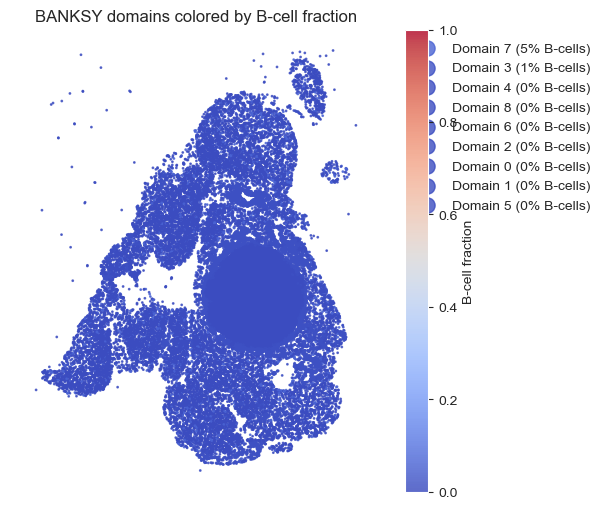

In [25]:
for basename, adata in adatas.items():
    stats_df = compute_domain_bcell_stats(adata)
    plot_domains_by_bcell_fraction(adata, stats_df)


In [ ]:
   # Interactive decision: select follicle domains
    # Example: top 3 domains by B-cell fraction
    follicle_domains = stats_df.head(3)["domain"].tolist()
    adata = assign_bcell_follicles(adata, follicle_domains)

    plot_bcell_follicles(adata, sample_name=basename)

Placeholder for Spatially Constrained GC B / Plasmablast Assignment

In [ ]:
for basename, adata in adatas.items():
    # Placeholder: here you will spatially prune subtypes
    # Example:
    # adata = spatially_define_celltype(
    #     adata,
    #     celltype_key="subtype_B_GC",
    #     domain_key="B_follicle",
    #     inside=True  # True = keep only inside follicle
    # )

    # adata = spatially_define_celltype(
    #     adata,
    #     celltype_key="subtype_B_plasmablast",
    #     domain_key="B_follicle",
    #     inside=False  # True = keep only inside follicle
    # )

    print(f"Spatial pruning placeholder for {basename}")


In [ ]:
for basename, adata in adatas.items():
    df_summary = summarize_celltypes_IHOPE(
        adata,
        filename=f"{basename}_filtered_arcsinh_cf5.0_IHOPE_summary_updated.csv"
    )


Updated summary tables